# 05 - Label Construction

**Inputs**:
- `features.parquet` — monthly decision-point features from 04_feature_engineering
- `options_clean.parquet` — cleaned options data from 02_data_cleaning

**Outputs**:
- `modeling_data.parquet` — complete dataset with features + labels

**Label**: Best-performing bucket (0-8) based on realized covered call returns

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

# Paths
PROCESSED = Path('../data/processed')

# Universe
UNIVERSE = ['AAPL', 'AMZN', 'GOOG', 'META', 'MSFT', 'NVDA', 'SHAK']

print(f"Universe: {UNIVERSE}")

Universe: ['AAPL', 'AMZN', 'GOOG', 'META', 'MSFT', 'NVDA', 'SHAK']


## 1. Load Data

In [2]:
# Load features from 04_feature_engineering
features = pd.read_parquet(PROCESSED / 'features.parquet')
print(f"Features: {features.shape}")

# Load options data
options = pd.read_parquet(PROCESSED / 'options_clean.parquet')
print(f"Options: {options.shape}")

# Load daily prices for payoff calculation
daily = pd.read_parquet(PROCESSED / 'daily_clean.parquet')
print(f"Daily prices: {daily.shape}")

Features: (840, 33)
Options: (657414, 20)
Daily prices: (27516, 10)


In [3]:
# Filter to universe
options = options[options['symbol'].isin(UNIVERSE)].copy()
daily = daily[daily['symbol'].isin(UNIVERSE)].copy()

# Filter to calls only
calls = options[options['call_put'] == 'CALL'].copy()

# Parse dates
calls['expiration'] = pd.to_datetime(calls['expiration'])
calls['trade_date'] = pd.to_datetime(calls['trade_date'])
daily['date'] = pd.to_datetime(daily['date'])

# Calculate DTE
calls['dte'] = (calls['expiration'] - calls['trade_date']).dt.days

print(f"Call options: {len(calls):,}")
print(f"Date range: {calls['trade_date'].min()} to {calls['trade_date'].max()}")

Call options: 322,053
Date range: 2015-02-02 00:00:00 to 2025-12-01 00:00:00


## 2. Assign Buckets

In [4]:
# Bucket boundaries (from 03b analysis)
def assign_moneyness_bucket(delta):
    """Assign moneyness bucket based on delta."""
    if 0.15 <= delta < 0.30:
        return 'OTM10'
    elif 0.30 <= delta < 0.45:
        return 'OTM5'
    elif 0.45 <= delta <= 0.60:
        return 'ATM'
    else:
        return None

def assign_maturity_bucket(dte):
    """Assign maturity bucket based on DTE."""
    if 7 <= dte <= 37:
        return 'DTE30'
    elif 38 <= dte <= 75:
        return 'DTE60'
    elif 76 <= dte <= 120:
        return 'DTE90'
    else:
        return None

# Assign buckets
calls['moneyness_bucket'] = calls['delta'].apply(assign_moneyness_bucket)
calls['maturity_bucket'] = calls['dte'].apply(assign_maturity_bucket)

# Filter to valid buckets only
calls_valid = calls.dropna(subset=['moneyness_bucket', 'maturity_bucket']).copy()
calls_valid['bucket'] = calls_valid['moneyness_bucket'] + '_' + calls_valid['maturity_bucket']

print(f"Valid bucket contracts: {len(calls_valid):,} ({len(calls_valid)/len(calls)*100:.1f}%)")
print(f"\nBucket distribution:")
print(calls_valid['bucket'].value_counts().sort_index())

Valid bucket contracts: 52,184 (16.2%)

Bucket distribution:
bucket
ATM_DTE30      11889
ATM_DTE60       4653
ATM_DTE90       1111
OTM10_DTE30    12754
OTM10_DTE60     3974
OTM10_DTE90     1150
OTM5_DTE30     11450
OTM5_DTE60      4171
OTM5_DTE90      1032
Name: count, dtype: int64


## 3. Compute Realized Payoffs

For each option contract, compute the realized covered call payoff:
- **Premium received**: mark price at entry
- **Stock P&L**: capped at strike if assigned
- **Total return**: (Premium + Stock P&L) / Entry Price

In [5]:
# Prepare daily prices for merging
daily_prices = daily[['symbol', 'date', 'adjusted_close']].copy()
daily_prices = daily_prices.rename(columns={'adjusted_close': 'price'})
daily_prices = daily_prices.sort_values(['symbol', 'date'])

print(f"Daily prices: {len(daily_prices):,}")

Daily prices: 19,343


In [6]:
# Merge entry price (trade_date)
calls_valid = calls_valid.merge(
    daily_prices.rename(columns={'date': 'trade_date', 'price': 'entry_price'}),
    on=['symbol', 'trade_date'],
    how='left'
)

print(f"Contracts with entry price: {calls_valid['entry_price'].notna().sum():,}")

Contracts with entry price: 52,184


In [7]:
# Merge exit price (expiration date or closest prior trading day)
# merge_asof requires global sort on the 'on' key, so we merge per-symbol
daily_exit = daily_prices.rename(columns={'date': 'expiration', 'price': 'exit_price'})

results = []
for sym in UNIVERSE:
    left = calls_valid[calls_valid['symbol'] == sym].sort_values('expiration')
    right = daily_exit[daily_exit['symbol'] == sym].sort_values('expiration')
    merged = pd.merge_asof(left, right[['expiration', 'exit_price']], on='expiration', direction='backward')
    results.append(merged)

calls_valid = pd.concat(results, ignore_index=True)

print(f"Contracts with exit price: {calls_valid['exit_price'].notna().sum():,}")

Contracts with exit price: 52,184


In [8]:
# Compute realized payoff
df = calls_valid.copy()

# Premium received (use mark price, or mid of bid/ask)
df['premium'] = df['mark'].fillna((df['bid'] + df['ask']) / 2)

# Stock P&L (capped at strike if ITM at expiration)
# If exit_price > strike, stock is called away at strike
df['stock_pnl'] = np.minimum(df['exit_price'], df['strike']) - df['entry_price']

# Total P&L = premium received + stock P&L
df['total_pnl'] = df['premium'] + df['stock_pnl']

# Return (as percentage of entry price)
df['return'] = df['total_pnl'] / df['entry_price']

# Annualized return (for comparison across different DTEs)
df['annualized_return'] = df['return'] * (365 / df['dte'].clip(lower=1))

# Was the option assigned? (stock price > strike at expiration)
df['assigned'] = (df['exit_price'] > df['strike']).astype(int)

print(f"Payoffs computed: {len(df):,}")
print(f"\nReturn statistics:")
print(df['return'].describe())

Payoffs computed: 52,184

Return statistics:
count    52184.000000
mean         0.391029
std          0.520883
min         -0.415299
25%          0.051709
50%          0.221235
75%          0.573822
max          5.008736
Name: return, dtype: float64


In [9]:
# Filter out extreme outliers (likely data errors)
pre_filter = len(df)
df = df[(df['return'] > -0.5) & (df['return'] < 0.5)].copy()
df = df[df['entry_price'] > 0].copy()
df = df[df['premium'] > 0].copy()

print(f"Removed {pre_filter - len(df):,} outliers")
print(f"Remaining contracts: {len(df):,}")

Removed 15,243 outliers
Remaining contracts: 36,941


In [10]:
# Return distribution by bucket
bucket_stats = df.groupby('bucket').agg({
    'return': ['mean', 'std', 'count'],
    'assigned': 'mean'
}).round(4)
bucket_stats.columns = ['mean_return', 'std_return', 'n_contracts', 'assignment_rate']
bucket_stats = bucket_stats.sort_index()

print("Return statistics by bucket:")
bucket_stats

Return statistics by bucket:


,mean_return,std_return,n_contracts,assignment_rate
bucket,,,,
ATM_DTE30,0.1345,0.1811,6535,0.2848
ATM_DTE60,0.0681,0.1481,1754,0.4048
ATM_DTE90,0.0748,0.1264,188,0.3777
OTM10_DTE30,0.1118,0.1371,11874,0.0817
OTM10_DTE60,0.1396,0.1568,3506,0.0767
OTM10_DTE90,0.1836,0.1704,777,0.0489
OTM5_DTE30,0.1638,0.1726,9175,0.1518
OTM5_DTE60,0.1733,0.1982,2793,0.1647
OTM5_DTE90,0.1918,0.1940,339,0.1593


## 4. Aggregate to Monthly Decision Points

In [11]:
# Add year_month for matching with decision points
df['year_month'] = df['trade_date'].dt.to_period('M')

# Aggregate returns by symbol, year_month, bucket
bucket_returns = df.groupby(['symbol', 'year_month', 'bucket']).agg({
    'return': 'mean',
    'annualized_return': 'mean',
    'assigned': 'mean',
    'premium': 'mean',
    'contractid': 'count'
}).rename(columns={'contractid': 'n_contracts'}).reset_index()

print(f"Bucket-month observations: {len(bucket_returns):,}")
bucket_returns.head(10)

Bucket-month observations: 3,994


,symbol,year_month,bucket,return,annualized_return,assigned,premium,n_contracts
0,AAPL,2015-02,ATM_DTE30,0.189113,3.274025,0.0,2.861000,10
1,AAPL,2015-02,ATM_DTE60,0.222284,1.602262,0.0,4.473750,8
2,AAPL,2015-02,ATM_DTE90,0.333264,1.192562,0.0,6.280000,1
3,AAPL,2015-02,OTM10_DTE30,0.117628,2.208743,0.0,0.877000,10
4,AAPL,2015-02,OTM10_DTE60,0.106691,0.766230,0.0,1.419231,13
5,AAPL,2015-02,OTM10_DTE90,0.182170,0.651881,0.0,2.310000,2
6,AAPL,2015-02,OTM5_DTE30,0.146533,2.642741,0.0,1.667273,11
7,AAPL,2015-02,OTM5_DTE60,0.165825,1.045513,0.0,2.990000,8
8,AAPL,2015-02,OTM5_DTE90,0.257146,0.920179,0.0,4.280000,1
9,AAPL,2015-03,ATM_DTE30,0.101042,1.443116,0.0,3.863333,9


In [12]:
# Check coverage: how many buckets per symbol-month?
coverage = bucket_returns.groupby(['symbol', 'year_month']).size().reset_index(name='n_buckets')
print("Bucket coverage per decision point:")
print(coverage['n_buckets'].value_counts().sort_index())

# Filter to decision points with all 9 buckets (for clean comparison)
full_coverage = coverage[coverage['n_buckets'] == 9][['symbol', 'year_month']]
print(f"\nDecision points with all 9 buckets: {len(full_coverage):,}")

Bucket coverage per decision point:
n_buckets
1     31
2     34
3     79
4     30
5     71
6    357
7     35
8     32
9     60
Name: count, dtype: int64

Decision points with all 9 buckets: 60


## 5. Construct Labels

In [13]:
# Find best bucket per symbol-month (highest mean return)
best_idx = bucket_returns.groupby(['symbol', 'year_month'])['return'].idxmax()
best_buckets = bucket_returns.loc[best_idx][['symbol', 'year_month', 'bucket', 'return']].copy()
best_buckets = best_buckets.rename(columns={'bucket': 'best_bucket', 'return': 'best_return'})

print(f"Decision points with labels: {len(best_buckets):,}")
print(f"\nBest bucket distribution (target labels):")
print(best_buckets['best_bucket'].value_counts().sort_index())

Decision points with labels: 729

Best bucket distribution (target labels):
best_bucket
ATM_DTE30      152
ATM_DTE60      160
ATM_DTE90       34
OTM10_DTE30     73
OTM10_DTE60    113
OTM10_DTE90     32
OTM5_DTE30      44
OTM5_DTE60      94
OTM5_DTE90      27
Name: count, dtype: int64


In [14]:
# Create numeric label (0-8)
bucket_to_label = {
    'ATM_DTE30': 0, 'ATM_DTE60': 1, 'ATM_DTE90': 2,
    'OTM5_DTE30': 3, 'OTM5_DTE60': 4, 'OTM5_DTE90': 5,
    'OTM10_DTE30': 6, 'OTM10_DTE60': 7, 'OTM10_DTE90': 8
}

label_to_bucket = {v: k for k, v in bucket_to_label.items()}

best_buckets['label'] = best_buckets['best_bucket'].map(bucket_to_label)

print("Label mapping:")
for bucket, label in sorted(bucket_to_label.items(), key=lambda x: x[1]):
    count = (best_buckets['label'] == label).sum()
    print(f"  {label}: {bucket} ({count} samples)")

Label mapping:
  0: ATM_DTE30 (152 samples)
  1: ATM_DTE60 (160 samples)
  2: ATM_DTE90 (34 samples)
  3: OTM5_DTE30 (44 samples)
  4: OTM5_DTE60 (94 samples)
  5: OTM5_DTE90 (27 samples)
  6: OTM10_DTE30 (73 samples)
  7: OTM10_DTE60 (113 samples)
  8: OTM10_DTE90 (32 samples)


## 6. Merge Features with Labels

In [15]:
# Ensure year_month is Period type in both dataframes
features['year_month'] = pd.to_datetime(features['decision_date']).dt.to_period('M')

# Merge features with labels
modeling_data = features.merge(
    best_buckets[['symbol', 'year_month', 'best_bucket', 'best_return', 'label']],
    on=['symbol', 'year_month'],
    how='inner'
)

print(f"Modeling data shape: {modeling_data.shape}")
print(f"Features matched with labels: {len(modeling_data)} / {len(features)} ({len(modeling_data)/len(features)*100:.1f}%)")

Modeling data shape: (671, 36)
Features matched with labels: 671 / 840 (79.9%)


In [16]:
# Check for missing values in key columns
print("Missing values in target:")
print(f"  label: {modeling_data['label'].isna().sum()}")
print(f"  best_bucket: {modeling_data['best_bucket'].isna().sum()}")

# Drop rows with missing labels
modeling_data = modeling_data.dropna(subset=['label'])
modeling_data['label'] = modeling_data['label'].astype(int)

print(f"\nFinal modeling data: {len(modeling_data)} rows")

Missing values in target:
  label: 0
  best_bucket: 0

Final modeling data: 671 rows


## 7. EDA on Merged Dataset

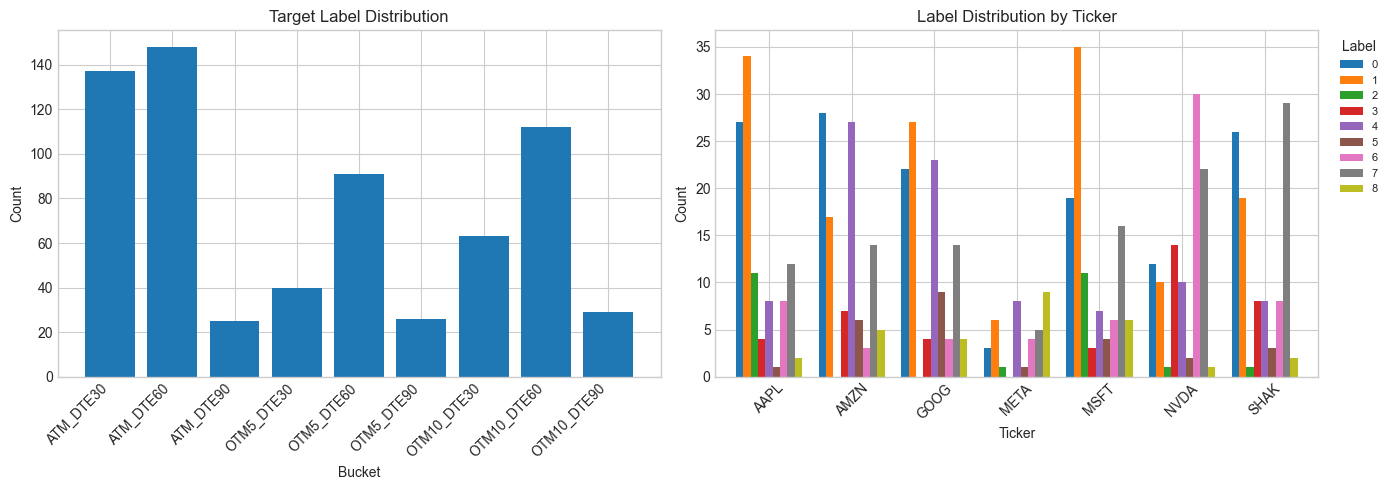

In [17]:
# Label distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall distribution
ax1 = axes[0]
label_counts = modeling_data['label'].value_counts().sort_index()
bars = ax1.bar(range(9), [label_counts.get(i, 0) for i in range(9)])
ax1.set_xticks(range(9))
ax1.set_xticklabels([label_to_bucket[i] for i in range(9)], rotation=45, ha='right')
ax1.set_xlabel('Bucket')
ax1.set_ylabel('Count')
ax1.set_title('Target Label Distribution')

# By ticker
ax2 = axes[1]
ticker_label = modeling_data.groupby(['symbol', 'label']).size().unstack(fill_value=0)
ticker_label.plot(kind='bar', ax=ax2, width=0.8)
ax2.set_xlabel('Ticker')
ax2.set_ylabel('Count')
ax2.set_title('Label Distribution by Ticker')
ax2.legend(title='Label', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/figures/label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# Class imbalance summary
label_pct = modeling_data['label'].value_counts(normalize=True).sort_index() * 100

print("Class distribution:")
for label in range(9):
    bucket = label_to_bucket[label]
    pct = label_pct.get(label, 0)
    print(f"  {label} ({bucket}): {pct:.1f}%")

print(f"\nImbalance ratio (max/min): {label_pct.max()/label_pct.min():.1f}x")

Class distribution:
  0 (ATM_DTE30): 20.4%
  1 (ATM_DTE60): 22.1%
  2 (ATM_DTE90): 3.7%
  3 (OTM5_DTE30): 6.0%
  4 (OTM5_DTE60): 13.6%
  5 (OTM5_DTE90): 3.9%
  6 (OTM10_DTE30): 9.4%
  7 (OTM10_DTE60): 16.7%
  8 (OTM10_DTE90): 4.3%

Imbalance ratio (max/min): 5.9x


In [19]:
# Feature-label correlation
feature_cols = [c for c in modeling_data.columns if c not in 
                ['symbol', 'decision_date', 'year_month', 'best_bucket', 'best_return', 'label', 
                 'adjusted_close', 'volume', 'fiscalDateEnding']]

# Compute correlation with label
correlations = modeling_data[feature_cols + ['label']].corr()['label'].drop('label').sort_values(key=abs, ascending=False)

print("Top 15 features correlated with label:")
print(correlations.head(15))

Top 15 features correlated with label:
mom_21d              0.429195
price_to_sma50       0.401844
price_to_sma21       0.371023
mom_63d              0.295207
drawdown_63d         0.261142
price_to_sma200      0.227453
mom_5d               0.219952
sma21_above_sma50    0.207451
cash_ratio           0.194034
gross_margin         0.164345
fcf_yield           -0.144198
drawdown_252d        0.131946
ps_ratio             0.124538
debt_to_equity      -0.115997
vol_63d              0.078637
Name: label, dtype: float64


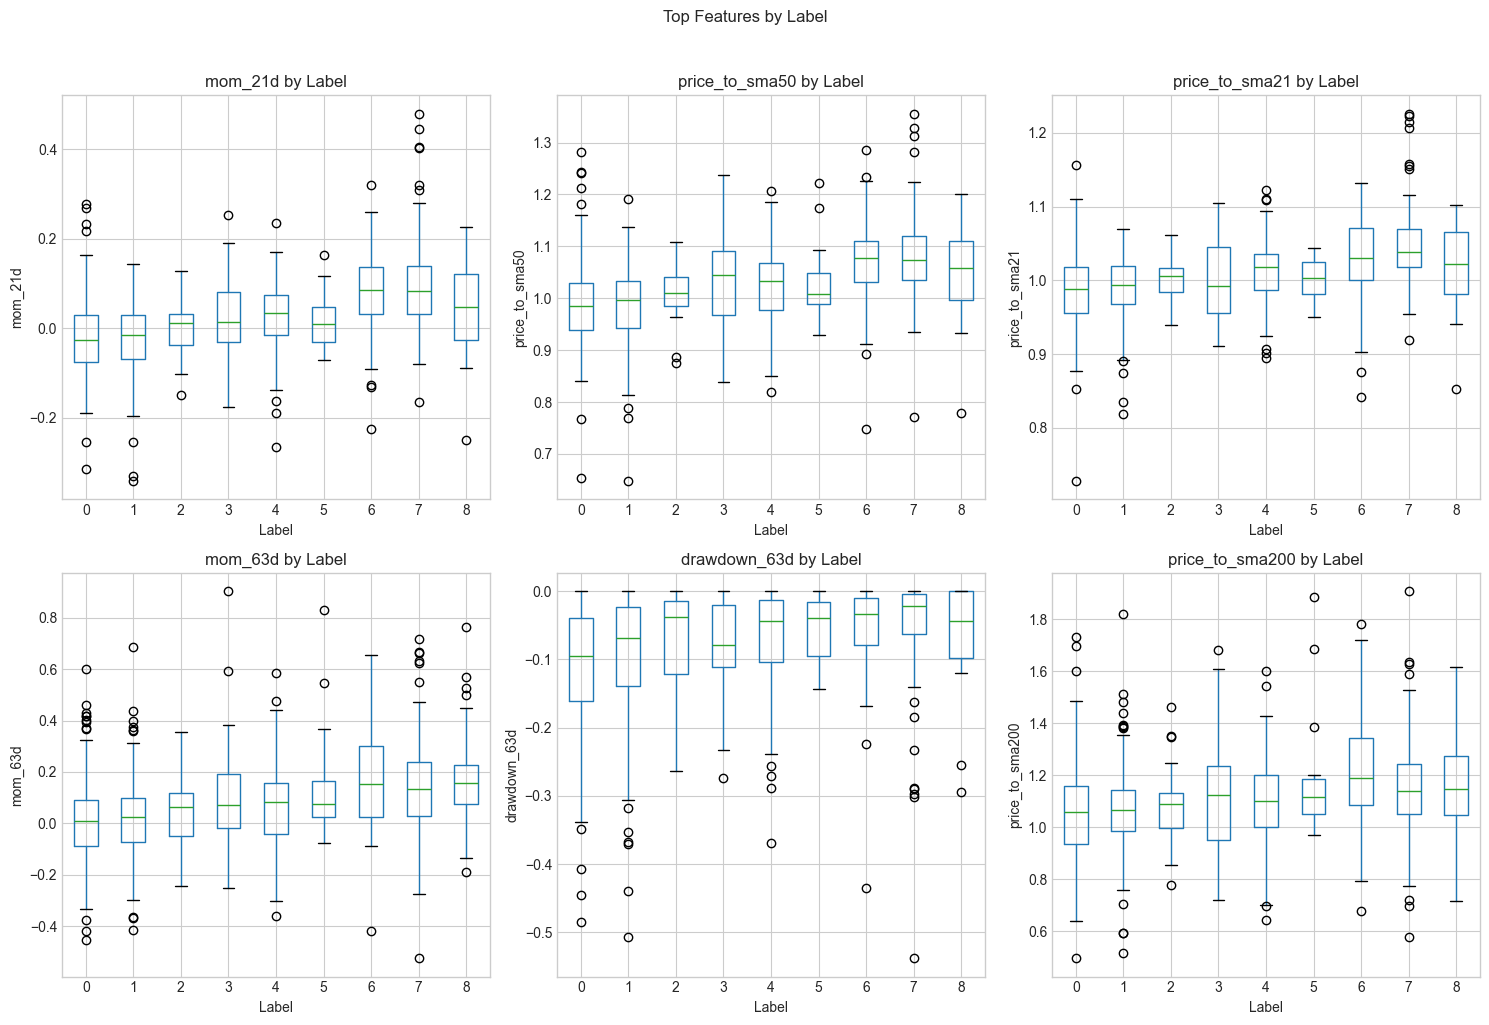

In [20]:
# Visualize top feature-label relationships
top_features = correlations.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    ax = axes[i]
    modeling_data.boxplot(column=feat, by='label', ax=ax)
    ax.set_xlabel('Label')
    ax.set_ylabel(feat)
    ax.set_title(f'{feat} by Label')

plt.suptitle('Top Features by Label', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/feature_label_relationships.png', dpi=150, bbox_inches='tight')
plt.show()

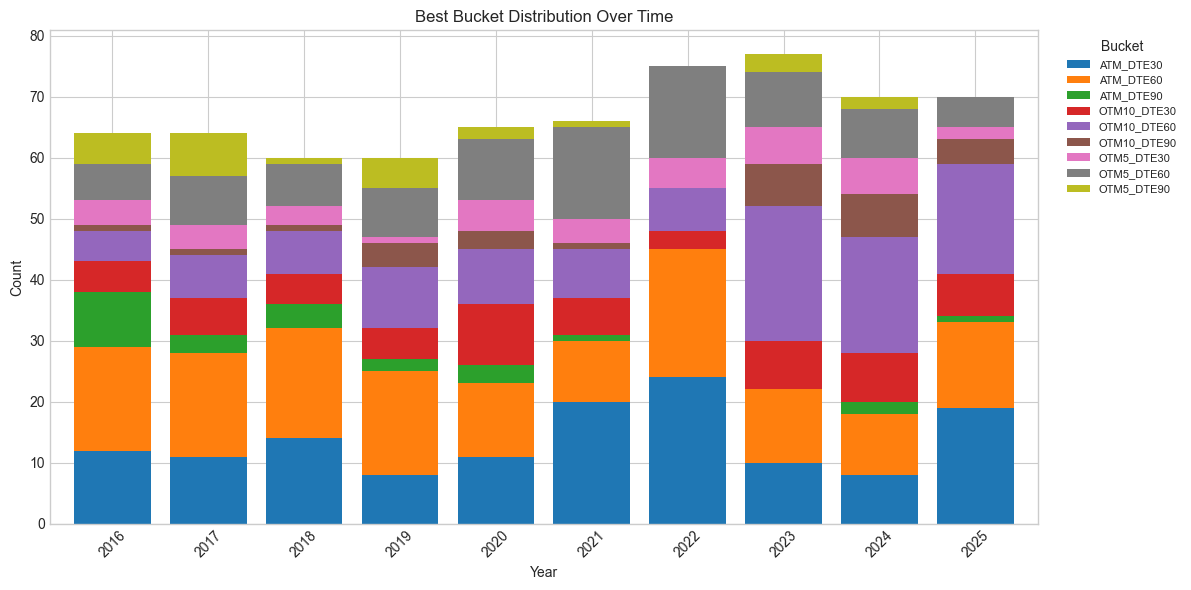

In [21]:
# Temporal analysis: does optimal bucket change over time?
modeling_data['year'] = pd.to_datetime(modeling_data['decision_date']).dt.year

yearly_labels = modeling_data.groupby(['year', 'best_bucket']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))
yearly_labels.plot(kind='bar', stacked=True, ax=ax, width=0.8)
ax.set_xlabel('Year')
ax.set_ylabel('Count')
ax.set_title('Best Bucket Distribution Over Time')
ax.legend(title='Bucket', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/figures/label_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

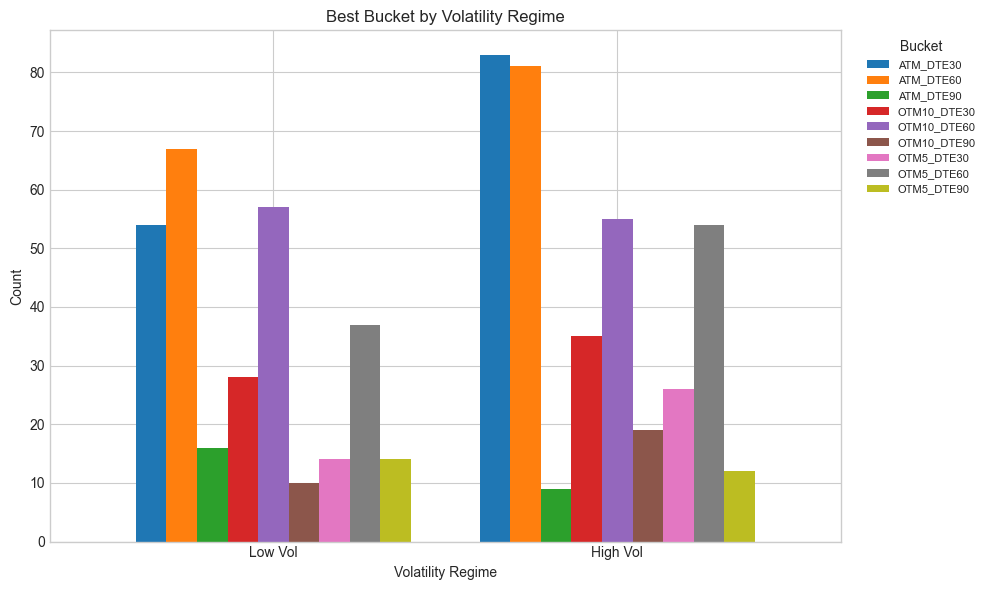

In [22]:
# Volatility regime vs best bucket
if 'high_vol_regime' in modeling_data.columns:
    vol_regime_labels = modeling_data.groupby(['high_vol_regime', 'best_bucket']).size().unstack(fill_value=0)
    vol_regime_labels.index = ['Low Vol', 'High Vol']
    
    fig, ax = plt.subplots(figsize=(10, 6))
    vol_regime_labels.plot(kind='bar', ax=ax, width=0.8)
    ax.set_xlabel('Volatility Regime')
    ax.set_ylabel('Count')
    ax.set_title('Best Bucket by Volatility Regime')
    ax.legend(title='Bucket', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    ax.tick_params(axis='x', rotation=0)
    
    plt.tight_layout()
    plt.savefig('../reports/figures/label_by_vol_regime.png', dpi=150, bbox_inches='tight')
    plt.show()

## 8. Compute Class Weights

In [23]:
# Compute class weights for imbalanced learning
from sklearn.utils.class_weight import compute_class_weight

classes = np.array(sorted(modeling_data['label'].unique()))
class_weights = compute_class_weight('balanced', classes=classes, y=modeling_data['label'])
class_weight_dict = dict(zip(classes, class_weights))

print("Class weights (for training):")
for label, weight in class_weight_dict.items():
    bucket = label_to_bucket[label]
    print(f"  {label} ({bucket}): {weight:.3f}")

Class weights (for training):
  0 (ATM_DTE30): 0.544
  1 (ATM_DTE60): 0.504
  2 (ATM_DTE90): 2.982
  3 (OTM5_DTE30): 1.864
  4 (OTM5_DTE60): 0.819
  5 (OTM5_DTE90): 2.868
  6 (OTM10_DTE30): 1.183
  7 (OTM10_DTE60): 0.666
  8 (OTM10_DTE90): 2.571


In [24]:
# Save class weights
import json

weights_path = PROCESSED / 'class_weights.json'
with open(weights_path, 'w') as f:
    json.dump({int(k): float(v) for k, v in class_weight_dict.items()}, f, indent=2)

print(f"Saved: {weights_path}")

Saved: ../data/processed/class_weights.json


## 9. Save Modeling Data

In [25]:
# Final column selection
id_cols = ['symbol', 'decision_date', 'year_month']
target_cols = ['label', 'best_bucket', 'best_return']

# All other columns are features
exclude_cols = id_cols + target_cols + ['year', 'fiscalDateEnding']
feature_cols = [c for c in modeling_data.columns if c not in exclude_cols]

print(f"ID columns: {len(id_cols)}")
print(f"Feature columns: {len(feature_cols)}")
print(f"Target columns: {len(target_cols)}")

ID columns: 3
Feature columns: 30
Target columns: 3


In [26]:
# Save modeling data
modeling_data.to_parquet(PROCESSED / 'modeling_data.parquet', index=False)
print(f"Saved: {PROCESSED / 'modeling_data.parquet'}")

# Save feature list
feature_list = pd.DataFrame({'feature': feature_cols})
feature_list.to_csv(PROCESSED / 'feature_list.csv', index=False)
print(f"Saved: {PROCESSED / 'feature_list.csv'}")

Saved: ../data/processed/modeling_data.parquet
Saved: ../data/processed/feature_list.csv


In [27]:
# Final summary
print("LABEL CONSTRUCTION COMPLETE")
print(f"Tickers: {modeling_data['symbol'].nunique()} ({', '.join(UNIVERSE)})")
print(f"Date range: {modeling_data['decision_date'].min()} to {modeling_data['decision_date'].max()}")
print(f"Total samples: {len(modeling_data)}")
print(f"Features: {len(feature_cols)}")
print(f"Classes: 9 (0-8)")
print(f"\nClass distribution:")
for label in range(9):
    count = (modeling_data['label'] == label).sum()
    pct = count / len(modeling_data) * 100
    print(f"  {label} ({label_to_bucket[label]}): {count} ({pct:.1f}%)")

LABEL CONSTRUCTION COMPLETE
Tickers: 7 (AAPL, AMZN, GOOG, META, MSFT, NVDA, SHAK)
Date range: 2016-02-29 00:00:00 to 2025-12-31 00:00:00
Total samples: 671
Features: 30
Classes: 9 (0-8)

Class distribution:
  0 (ATM_DTE30): 137 (20.4%)
  1 (ATM_DTE60): 148 (22.1%)
  2 (ATM_DTE90): 25 (3.7%)
  3 (OTM5_DTE30): 40 (6.0%)
  4 (OTM5_DTE60): 91 (13.6%)
  5 (OTM5_DTE90): 26 (3.9%)
  6 (OTM10_DTE30): 63 (9.4%)
  7 (OTM10_DTE60): 112 (16.7%)
  8 (OTM10_DTE90): 29 (4.3%)


In [28]:
# Preview final data
print("\nSample of modeling data:")
modeling_data[id_cols + target_cols + feature_cols[:5]].head(10)


Sample of modeling data:


,symbol,decision_date,year_month,label,best_bucket,best_return,adjusted_close,volume,vol_10d,vol_21d,vol_63d
0,AAPL,2016-02-29,2016-02,2,ATM_DTE90,0.269083,21.896748,35216277,0.246568,0.257725,0.305546
1,AAPL,2016-03-31,2016-03,1,ATM_DTE60,0.223296,24.682248,25888449,0.162471,0.153959,0.301129
2,AAPL,2016-04-29,2016-04,0,ATM_DTE30,0.003813,21.228681,68531478,0.302257,0.283225,0.249376
3,AAPL,2016-05-31,2016-05,2,ATM_DTE90,0.386473,22.752886,42307212,0.138158,0.204823,0.231319
4,AAPL,2016-06-30,2016-06,2,ATM_DTE90,0.384077,21.782255,35836356,0.244127,0.182192,0.234182
5,AAPL,2016-07-29,2016-07,1,ATM_DTE60,0.265831,23.744025,27733688,0.355779,0.255105,0.218197
6,AAPL,2016-08-31,2016-08,2,ATM_DTE90,0.271467,24.304812,29662406,0.068063,0.109241,0.196240
7,AAPL,2016-09-30,2016-09,1,ATM_DTE60,0.225240,25.896881,36379106,0.153542,0.263892,0.222941
8,AAPL,2016-10-31,2016-10,0,ATM_DTE30,0.129499,26.009127,26419398,0.135858,0.128148,0.178890
9,AAPL,2016-11-30,2016-11,1,ATM_DTE60,0.132696,25.448715,36162258,0.165689,0.208392,0.206238
